# Linear Regression

In [1]:
# Step 1 - Import the library:
from sklearn.linear_model import LinearRegression


In [2]:
# Step 2 - Create an instance of the model:
model = LinearRegression()


# Python Implementation (with Models)

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Sample Data: Predicting salary from years of experience
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([30000, 35000, 40000, 43000, 50000, 52000, 58000, 60000, 65000, 70000])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 1. Linear Regression

In [4]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred))


Linear Regression R²: 0.9989818668252081


In [ ]:
2. Polynomial Regression

# 2. Polynomial Regression

In [5]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)

y_pred_poly = poly_model.predict(poly.transform(X_test))
print("Polynomial Regression R²:", r2_score(y_test, y_pred_poly))


Polynomial Regression R²: 0.9994623417572753


# 3. Ridge Regression (L2 Regularization)

In [6]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
print("Ridge Regression R²:", r2_score(y_test, y_pred_ridge))



Ridge Regression R²: 0.9993685363401321


# 4. Lasso Regression (L1 Regularization)

In [7]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
print("Lasso Regression R²:", r2_score(y_test, y_pred_lasso))


Lasso Regression R²: 0.9989819944406922


# 5. Elastic Net Regression

In [8]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)
print("ElasticNet Regression R²:", r2_score(y_test, y_pred_elastic))


ElasticNet Regression R²: 0.9992101121197953


# 6. Logistic Regression (for Classification)

In [9]:
# Binary outcome example
y_class = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

log_model = LogisticRegression()
log_model.fit(X, y_class)
pred = log_model.predict([[4.5]])
print("Logistic Prediction for 4.5 years:", pred)


Logistic Prediction for 4.5 years: [1]


# 4. Visualizing Linear vs Polynomial Regression

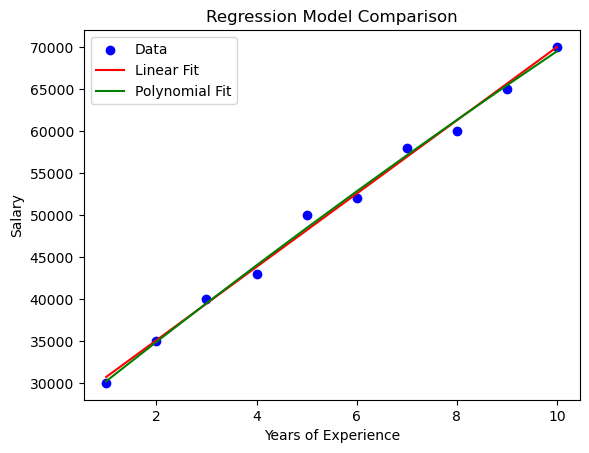

In [10]:
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, linear_model.predict(X), color='red', label='Linear Fit')
plt.plot(X, poly_model.predict(poly.transform(X)), color='green', label='Polynomial Fit')
plt.legend()
plt.title("Regression Model Comparison")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()


In [11]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# 2. Features and target
X = df.iloc[:, 0:4]
y = df['species']

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 7. Detailed results
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Select columns
df = df[['pclass', 'sex', 'age', 'fare', 'alone', 'survived']]

# Handle missing values
df['age'].fillna(df['age'].mean(), inplace=True)

# Convert categorical to numeric
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['alone'] = df['alone'].astype(int)

# Features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Train decision tree classifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


C:\Users\Aiza Iqbal\AppData\Local\Temp\ipykernel_10516\1724905504.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


Accuracy: 0.7533632286995515

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.80       134
           1       0.70      0.66      0.68        89

    accuracy                           0.75       223
   macro avg       0.74      0.74      0.74       223
weighted avg       0.75      0.75      0.75       223


Confusion Matrix:
[[109  25]
 [ 30  59]]


In [13]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.965034965034965

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143


Confusion Matrix:
[[51  3]
 [ 2 87]]
